El cojunto de datos es de enfermedades del corazón. 
URL: https://archive.ics.uci.edu/dataset/45/heart+disease

Cargar las librerías para el proyecto

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")

Descargar el dataset

In [2]:
# =========================================================
# 1. DESCARGAR DATASET
# =========================================================
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

In [3]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [4]:
y.head()

,num
0,0
1,2
2,1
3,0
4,0


PREPROCESAMIENTO DEL DATASET


=== INFORMACIÓN DEL DATASET ===
Dimensiones de X: (303, 13)
Distribución de clases:
num
0    164
1    139
Name: count, dtype: int64


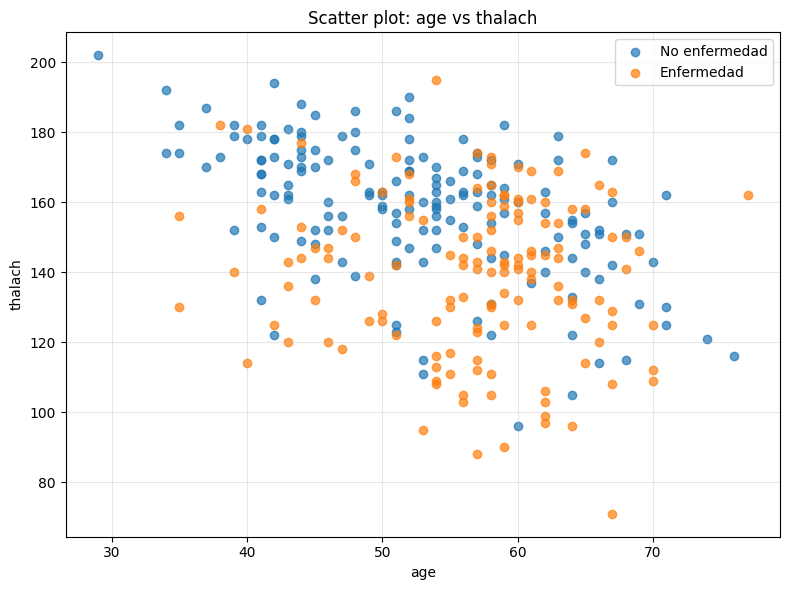

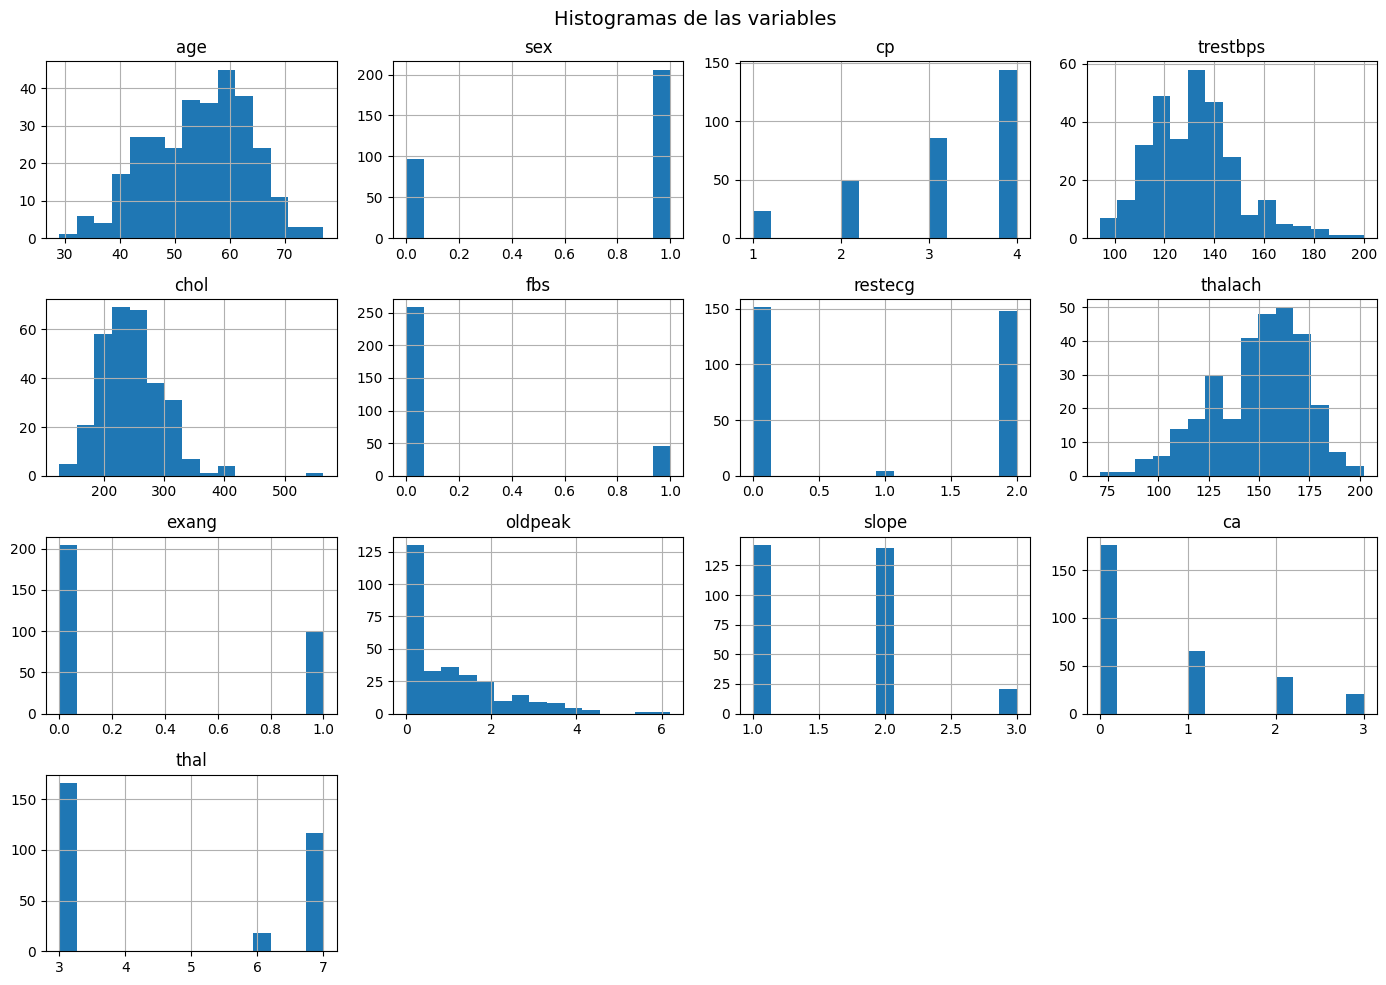

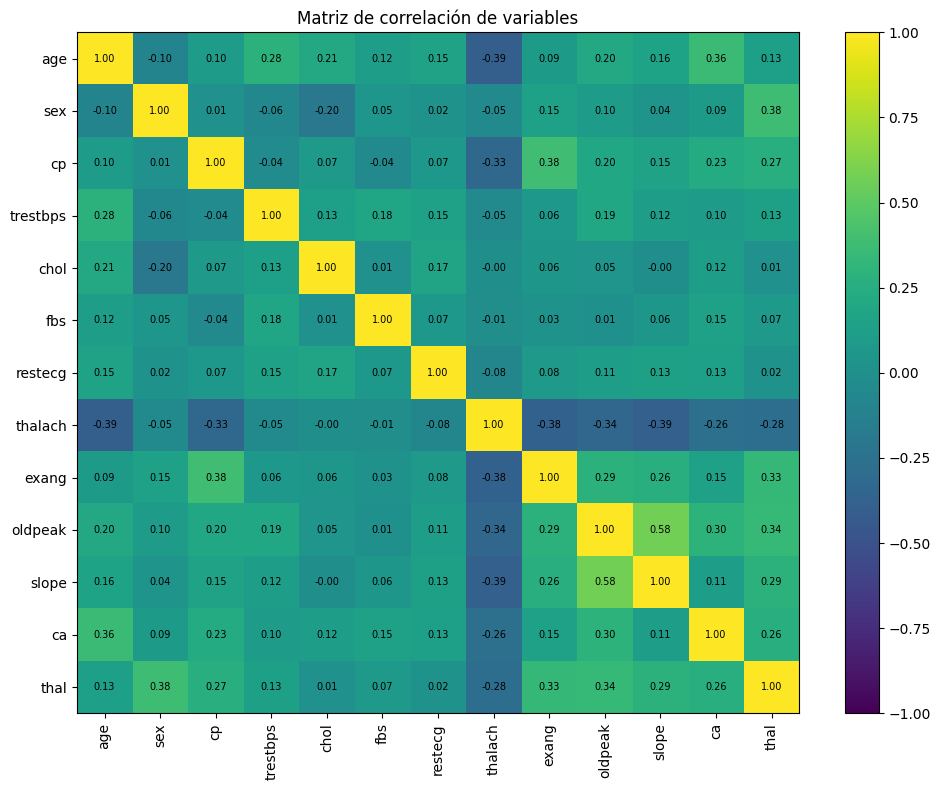

In [5]:
# =========================================================
# 2. PREPROCESADO + VISUALIZACIÓN
# =========================================================
# y puede venir como DataFrame de una columna
if isinstance(y, pd.DataFrame):
    y = y.squeeze()

# Reemplazar '?' por NaN si existiera en algunas columnas
X = X.replace("?", np.nan)
y = y.replace("?", np.nan)

# Convertir todo a numérico cuando sea posible
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Eliminar filas sin target
mask = y.notna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

# Convertir a clasificación binaria:
# 0 = no enfermedad
# 1 = presencia de enfermedad
y = (y > 0).astype(int)

print("\n=== INFORMACIÓN DEL DATASET ===")
print(f"Dimensiones de X: {X.shape}")
print(f"Distribución de clases:\n{y.value_counts().sort_index()}")

# =========================================================
# 2.1 VISUALIZACIÓN DE LOS DATOS
# =========================================================
# Copia para visualización
df_viz = X.copy()
df_viz["target"] = y

# Seleccionar columnas numéricas
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# ---------------------------------------------------------
# A) SCATTER PLOT
# ---------------------------------------------------------
# Elegir un par de variables representativas si existen
preferred_pairs = [
    ("age", "thalach"),
    ("age", "chol"),
    ("trestbps", "chol")
]

x_col, y_col = None, None
for c1, c2 in preferred_pairs:
    if c1 in numeric_cols and c2 in numeric_cols:
        x_col, y_col = c1, c2
        break

# Si no existen esas variables, usar las dos primeras numéricas
if x_col is None or y_col is None:
    if len(numeric_cols) >= 2:
        x_col, y_col = numeric_cols[0], numeric_cols[1]

if x_col is not None and y_col is not None:
    plt.figure(figsize=(8, 6))

    scatter_mask = df_viz[x_col].notna() & df_viz[y_col].notna()

    clase_0 = df_viz.loc[scatter_mask & (df_viz["target"] == 0)]
    clase_1 = df_viz.loc[scatter_mask & (df_viz["target"] == 1)]

    plt.scatter(clase_0[x_col], clase_0[y_col], alpha=0.7, label="No enfermedad")
    plt.scatter(clase_1[x_col], clase_1[y_col], alpha=0.7, label="Enfermedad")

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Scatter plot: {x_col} vs {y_col}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# B) HISTOGRAMAS
# ---------------------------------------------------------
X.hist(figsize=(14, 10), bins=15)
plt.suptitle("Histogramas de las variables", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# C) MATRIZ DE CORRELACIÓN
# ---------------------------------------------------------
corr_matrix = X.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, interpolation="nearest", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im)

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Matriz de correlación de variables")

# Anotar los valores de correlación dentro de la matriz
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()
plt.show()

MODELO DE LA RED NEURONAL

In [6]:
# =========================================================
# 3. MODELO MLP
# =========================================================
modelo = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64,32),   # capas ocultas
        activation="relu",             # función ReLU
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])

# Mostrar arquitectura elegida
print("\n=== ARQUITECTURA DE LA RED ===")
print("Capas ocultas:", modelo.named_steps["mlp"].hidden_layer_sizes)
print("Función de activación:", modelo.named_steps["mlp"].activation)


=== ARQUITECTURA DE LA RED ===
Capas ocultas: (64, 32)
Función de activación: relu


DIVISIÓN DEL DATASET K-FOLD


=== RESULTADOS VALIDACIÓN CRUZADA (10-FOLD) ===
ACCURACY  : 0.8348 ± 0.0667
PRECISION : 0.8685 ± 0.0991
RECALL    : 0.7692 ± 0.1156
F1        : 0.8081 ± 0.0772
ROC_AUC   : 0.9009 ± 0.0539

=== EVALUACIÓN GLOBAL ===
Accuracy: 0.8350
ROC AUC:  0.8939

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       164
           1       0.86      0.77      0.81       139

    accuracy                           0.83       303
   macro avg       0.84      0.83      0.83       303
weighted avg       0.84      0.83      0.83       303



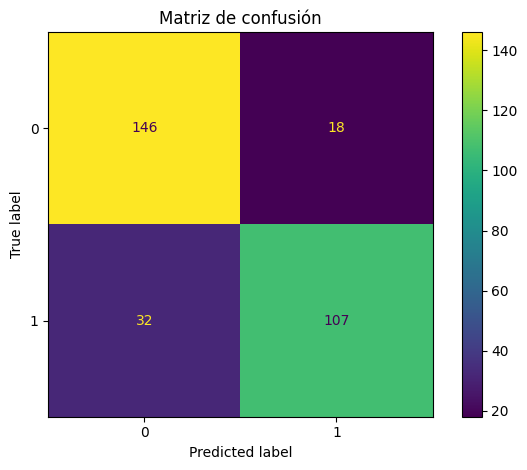

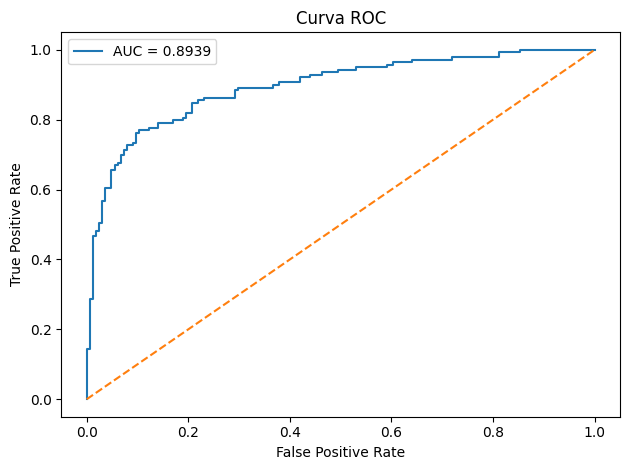

In [7]:
# =========================================================
# 4. VALIDACIÓN CRUZADA K-FOLD = 10
# =========================================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    modelo,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("\n=== RESULTADOS VALIDACIÓN CRUZADA (10-FOLD) ===")
for metric in scoring.keys():
    scores = cv_results[f"test_{metric}"]
    print(f"{metric.upper():10s}: {scores.mean():.4f} ± {scores.std():.4f}")

# Predicciones globales usando CV
y_pred = cross_val_predict(modelo, X, y, cv=cv, method="predict", n_jobs=-1)
y_prob = cross_val_predict(modelo, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

# =========================================================
# 5. EVALUACIÓN
# =========================================================
acc = accuracy_score(y, y_pred)
auc = roc_auc_score(y, y_prob)

print("\n=== EVALUACIÓN GLOBAL ===")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC:  {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
modelo.fit(X, y)

mlp_final = modelo.named_steps["mlp"]
print("\n=== RED ENTRENADA FINAL ===")
print("Capas ocultas:", mlp_final.hidden_layer_sizes)
print("Activación:", mlp_final.activation)
print("Número total de capas:", mlp_final.n_layers_)
print("Tamaño de la capa de salida:", mlp_final.n_outputs_)


=== RED ENTRENADA FINAL ===
Capas ocultas: (64, 32)
Activación: relu
Número total de capas: 4
Tamaño de la capa de salida: 1
